In [1]:
# Required for adding MySQL needed libraries
import sys
'''
!python3 -m pip install mysql-connector-python sqlalchemy pandas
!python3 -m pip install mysql-connector-python
!{sys.executable} -m pip install mysql-connector-python
'''
import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import mysql.connector as sql

from sqlalchemy import create_engine
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC # For SVM
from sklearn.ensemble import RandomForestClassifier # For Random Forest
from sklearn.inspection import permutation_importance
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report 
from sklearn.metrics import roc_curve, auc, precision_score, recall_score, f1_score
from sklearn.metrics import roc_auc_score

In [2]:
# Connecting to MySQL and loading data into database
conn = sql.connect(
    host="localhost",
    user="root",
    password="",
    database="cap6771",
)

print(conn.is_connected())

engine = create_engine("mysql+mysqlconnector://root:@localhost/cap6771")

# Getting training dataset and loading to MySQL
df_csv = pd.read_csv("/Users/luismadrigal/Downloads/archive/train.csv") 
df_csv.to_sql("baseball", con=engine, if_exists="replace", index=False)

# Getting testing dataset and loading to MySQL
df_test = pd.read_csv("/Users/luismadrigal/Downloads/archive/test.csv")
df_test.to_sql("test", con=engine, if_exists="replace", index=False)

# Getting park dataset and loading to MySQL
df_park = pd.read_csv("/Users/luismadrigal/Downloads/archive/park_dimensions.csv")
df_park.to_sql("park_dimensions", con=engine, if_exists="replace", index=False)

# Verifying dataset loaded into MySQL
pd.read_sql("SHOW TABLES", engine) 
pd.read_sql("SELECT COUNT(*) AS total_rows FROM baseball", engine)
conn.close()

True


In [3]:
# Data Collection
baseball = pd.read_sql("SELECT * FROM baseball", engine)
data = pd.read_sql("SELECT * FROM baseball", engine)

In [4]:
# Data Prepocessing

# Removing instances with missing values in key features
baseball = baseball.dropna(subset=["launch_speed","launch_angle"]).copy()

# Replacing NULL values
baseball["bb_type"] = baseball["bb_type"].fillna("Unknown")

# Dropping low variance and high cardinality columns
dropped_low_variance = []
dropped_high_cardinality = []

for col in baseball.columns:
    if baseball[col].nunique() <= 1:
        dropped_low_variance.append(col)

for col in baseball.columns:
    if baseball[col].nunique() == len(baseball):
        dropped_high_cardinality.append(col)

# Dropping first set of columns
baseball = baseball.drop(columns=dropped_low_variance + dropped_high_cardinality)
print("Low variance dropped:", dropped_low_variance)
print("High cardinality dropped:", dropped_high_cardinality)

# Dropping second set of columns
cols_to_drop = ["bip_id", "batter_id", "pitcher_id", "batter_name", "pitcher_name"]
baseball = baseball.drop(columns=cols_to_drop, errors="ignore")

# Input and Output Data
X = baseball.drop(columns=["is_home_run"])
y = baseball["is_home_run"]

# One-Hot Encoding (required for SVM and Random Forest)
X = pd.get_dummies(X,drop_first=True)

# Split 70% train, 30% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Standardization (required for SVM and Logistic Regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Low variance dropped: []
High cardinality dropped: ['bip_id']


Original Data:
    bip_id   game_date home_team away_team batter_team        batter_name  \
0       1  2020-08-26       ARI       COL         COL     arenado, nolan   
1       2  2020-08-10       COL       ARI         COL     arenado, nolan   
2       3  2020-08-10       COL       ARI         COL     arenado, nolan   
3       4  2020-08-26       ARI       COL         COL  blackmon, charlie   
4       5  2020-08-10       COL       ARI         COL  blackmon, charlie   

  pitcher_name  batter_id  pitcher_id  is_batter_lefty  ...  inning  \
0  ray, robbie     571448      592662                0  ...       1   
1  ray, robbie     571448      592662                0  ...       1   
2  ray, robbie     571448      592662                0  ...       3   
3  ray, robbie     453568      592662                1  ...       1   
4  ray, robbie     453568      592662                1  ...       1   

  outs_when_up balls strikes  plate_x  plate_z  pitch_mph  launch_speed  \
0            0     1     

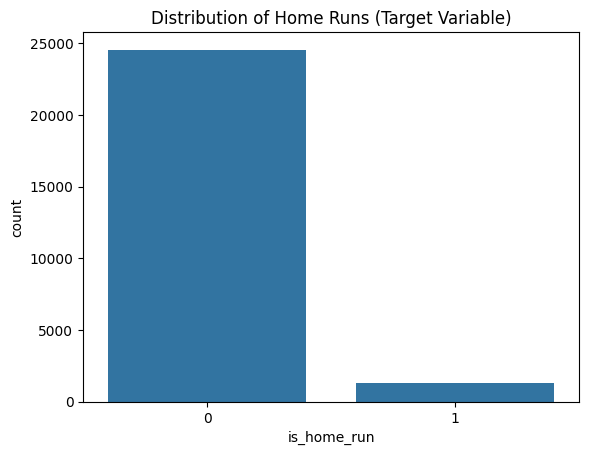

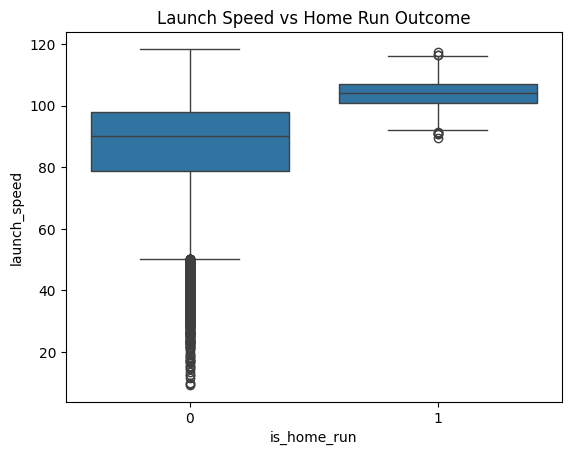

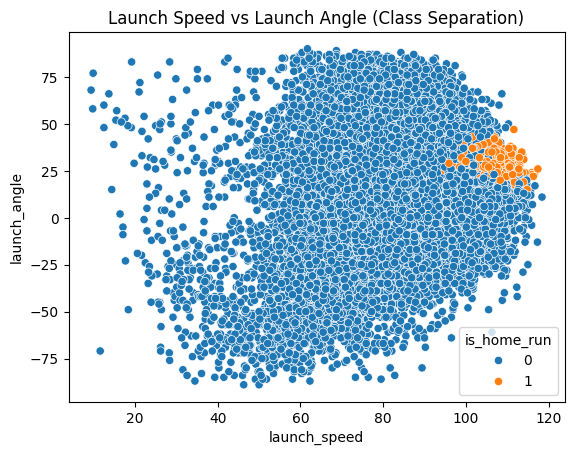

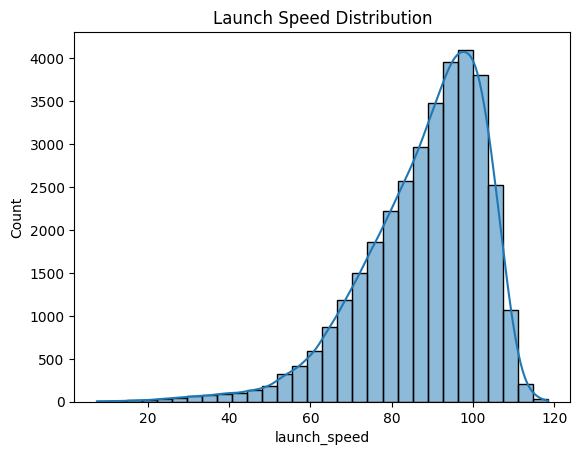

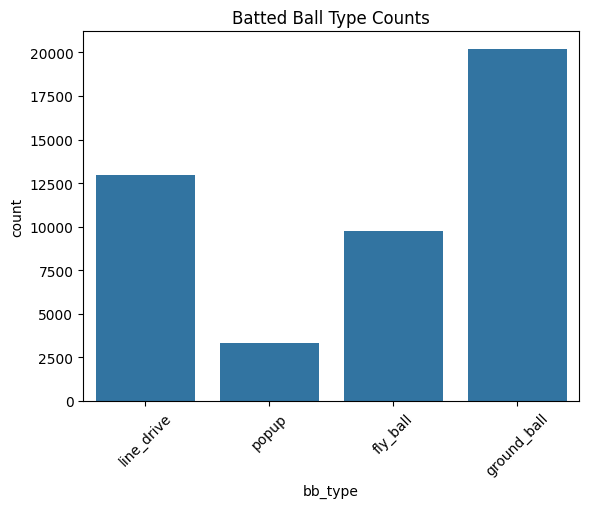

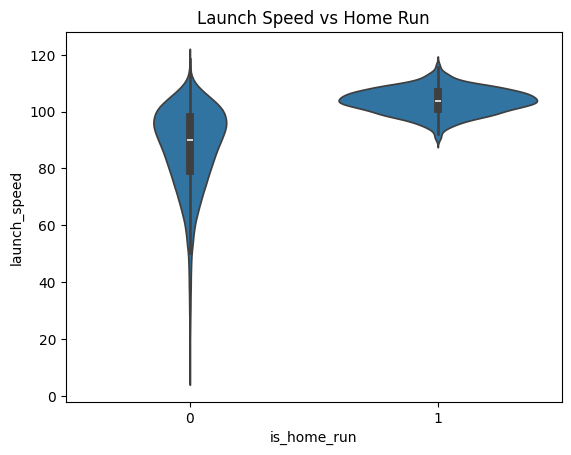

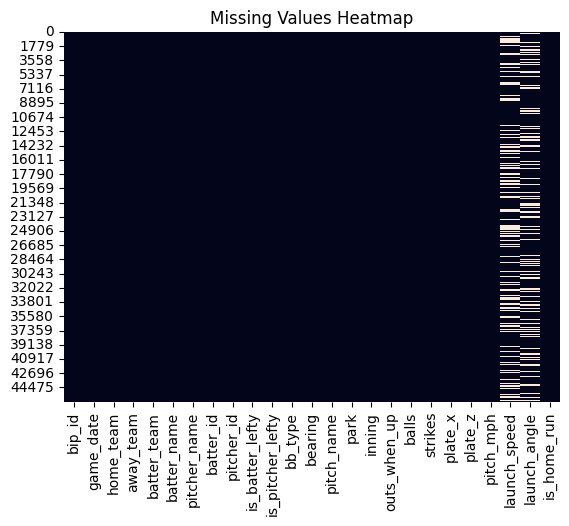

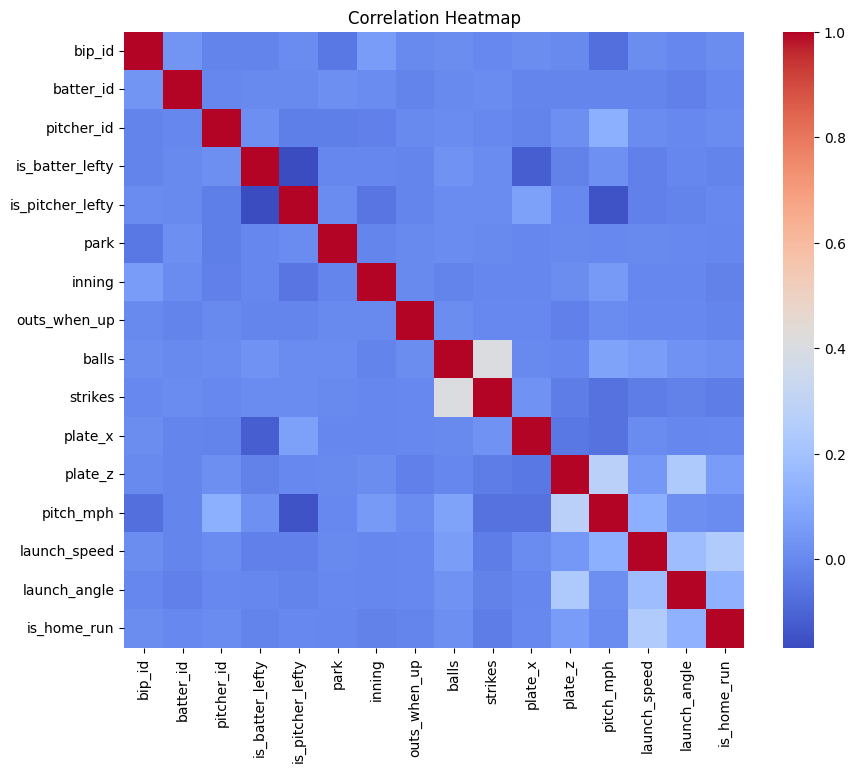

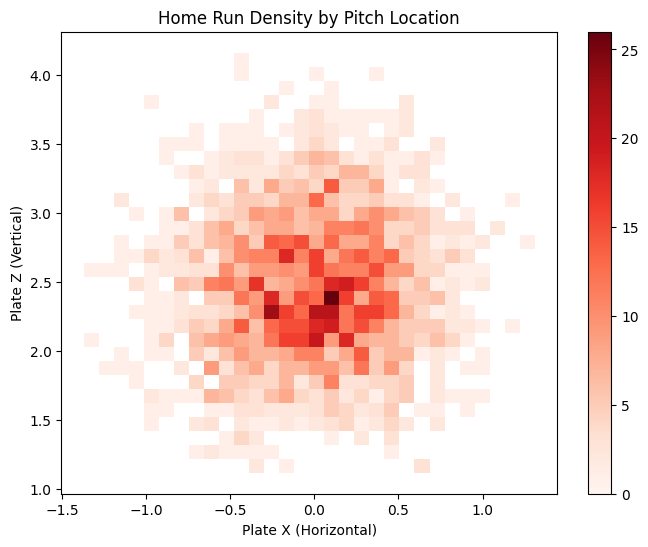

In [5]:
# Data Exploration
print("Original Data:\n",data.head())
print(data.info())
print("Original Instances, Features:",data.shape)
print("Original Duplicates:",data.duplicated().sum())
print("Original Nulls:\n",data.isna().sum())

print("\nProcessed Data:")
print(baseball.info()) # Showing modified/processed data 
print(baseball.describe())
print("Instances, Features:",baseball.shape)
print("Duplicates:",baseball.duplicated().sum())
print("Nulls:\n",baseball.isna().sum())

# Visualizing data
sns.countplot(x='is_home_run', data=baseball)
plt.title("Distribution of Home Runs (Target Variable)")
plt.show()

sns.boxplot(x='is_home_run', y='launch_speed', data=baseball)
plt.title("Launch Speed vs Home Run Outcome")
plt.show()

sns.scatterplot(
    x='launch_speed',
    y='launch_angle',
    hue='is_home_run',
    data=baseball
)
plt.title("Launch Speed vs Launch Angle (Class Separation)")
plt.show()

# Correlation
corr_matrix = data.corr(numeric_only=True)
corr_matrix

# Feature Distribution
sns.histplot(data["launch_speed"], bins=30, kde=True)
plt.title("Launch Speed Distribution")
plt.show()

# Feature Counts
sns.countplot(x="bb_type", data=data)
plt.xticks(rotation=45)
plt.title("Batted Ball Type Counts")
plt.show()

# Violin Plot (Launch vs Home)
sns.violinplot(x="is_home_run", y="launch_speed", data=data)
plt.title("Launch Speed vs Home Run")
plt.show()

# Missing value heatmap
data.isnull().sum()
(data.isnull().sum() / len(data)) * 100
sns.heatmap(data.isnull(), cbar=False)
plt.title("Missing Values Heatmap")
plt.show()

# Correlation heatmap
plt.figure(figsize=(10,8))
sns.heatmap(data.corr(numeric_only=True), annot=False, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

# Density plot
# Filter only home runs
hr_data = data[data["is_home_run"] == 1]

plt.figure(figsize=(8,6))

sns.histplot(
    data=hr_data,
    x="plate_x",
    y="plate_z",
    bins=30,
    cmap="Reds",
    cbar=True
)

plt.title("Home Run Density by Pitch Location")
plt.xlabel("Plate X (Horizontal)")
plt.ylabel("Plate Z (Vertical)")
plt.show()

/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


Most Important Features:
                   feature      coef
10           launch_speed  6.023216
11           launch_angle  2.801023
188      bb_type_fly_ball  2.071537
190    bb_type_line_drive  1.975738
2                    park  0.405411
115         home_team_MIL  0.382354
105         home_team_CIN  0.345285
104         home_team_CHC  0.320699
118         home_team_NYY  0.317285
56   game_date_2020-09-06  0.315429

Least Important Features:
                   feature      coef
97   game_date_2020-10-23 -0.334528
184        batter_team_TB -0.338061
186       batter_team_TOR -0.340592
99   game_date_2020-10-25 -0.340951
179       batter_team_PIT -0.352821
161       batter_team_BOS -0.409166
119         home_team_OAK -0.436288
164       batter_team_CLE -0.490043
191         bb_type_popup -2.173884
189   bb_type_ground_ball -2.353807
Logistic Regression Performance
Confusion Matrix:
 [[6519  846]
 [  55  340]]
Accuracy: 0.8838917525773196
Precision: 0.2866779089376054
Recall: 0.8607594

/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalt

CV AUC scores: [0.94749035 0.94514933 0.94683495 0.95525515 0.94806028]
Mean CV AUC: 0.9485580143302297


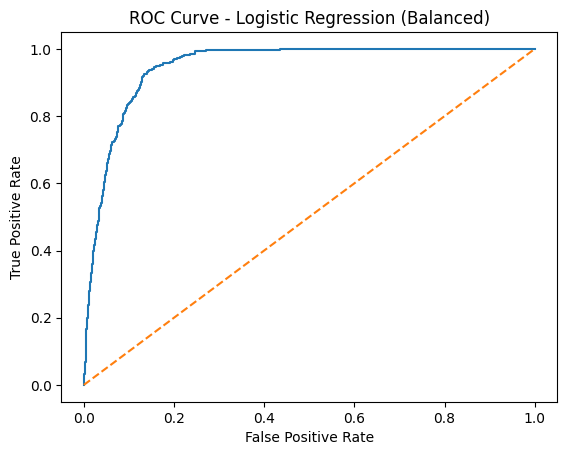

In [8]:
# Logistic Regression Model
logModel= LogisticRegression(penalty=None, max_iter=5000, class_weight='balanced')
logModel.fit(X_train_scaled, np.ravel(y_train))

# Identifying most/least important features
features= X.columns
coef= logModel.coef_[0]

importance= pd.DataFrame({
    'feature': features,
    'coef': coef
        }).sort_values(by='coef', ascending=False)

print("Most Important Features:\n",importance.head(10))
print("\nLeast Important Features:\n",importance.tail(10))

# Predictions
log_pred= logModel.predict(X_test_scaled)
log_prob= logModel.predict_proba(X_test_scaled)[:,1]

# Performance Metrics
print("Logistic Regression Performance\nConfusion Matrix:\n", confusion_matrix(np.ravel(y_test), log_pred))
print("Accuracy:", accuracy_score(np.ravel(y_test), log_pred))
print("Precision:", precision_score(np.ravel(y_test), log_pred))
print("Recall:", recall_score(np.ravel(y_test), log_pred))
print("F1 Score:", f1_score(y_test, log_pred))
print("ROC AUC:", roc_auc_score(y_test, log_prob))

# Cross Validation Scoring
cv_scores = cross_val_score(
    logModel,
    X_train_scaled,
    y_train,
    cv=5,
    scoring='roc_auc'
)
print("CV AUC scores:", cv_scores)
print("Mean CV AUC:", cv_scores.mean())

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, log_prob)
plt.plot(fpr, tpr)
plt.plot([0,1],[0,1],'--')
plt.title("ROC Curve - Logistic Regression (Balanced)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.show()

SVM Summary and Performance

         Parameter     Value
0           Kernel       rbf
1                C       1.0
2            Gamma     scale
3     Class Weight  balanced
4  Support Vectors      5799
Confusion Matrix:
 [[6787  578]
 [ 145  250]]
Accuracy: 0.9068298969072165
Report:
               precision    recall  f1-score   support

           0       0.98      0.92      0.95      7365
           1       0.30      0.63      0.41       395

    accuracy                           0.91      7760
   macro avg       0.64      0.78      0.68      7760
weighted avg       0.94      0.91      0.92      7760



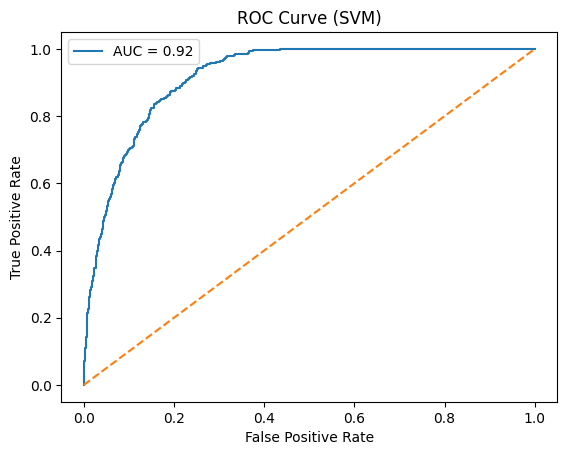

CV Scores: [0.89729431 0.90499862 0.90720795 0.90693179 0.89312345]
CV Mean: 0.9019112237330829

UNBALANCED SVM (RBF)
Accuracy: 0.9490979381443299
Precision: 0.0
Recall: 0.0
F1-Score: 0.0
Confusion Matrix:
 [[7365    0]
 [ 395    0]]
              precision    recall  f1-score   support

           0       0.95      1.00      0.97      7365
           1       0.00      0.00      0.00       395

    accuracy                           0.95      7760
   macro avg       0.47      0.50      0.49      7760
weighted avg       0.90      0.95      0.92      7760



/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/lib/python3.13/sit

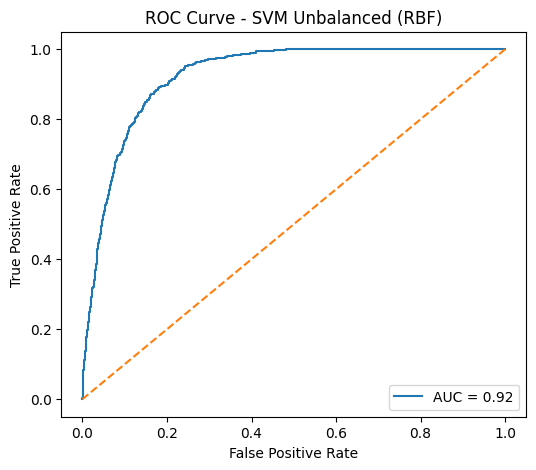

In [11]:
# SVM Model
# kernels, class_weight, random_state
svmModel = SVC(kernel='rbf', class_weight='balanced', random_state=42)
svmModel.fit(X_train_scaled, y_train)

# Parameter Summary
model_summary = pd.DataFrame({
    "Parameter": ["Kernel", "C", "Gamma", "Class Weight", "Support Vectors"],
    "Value": [
        svmModel.kernel,
        svmModel.C,
        svmModel.gamma,
        svmModel.class_weight,
        len(svmModel.support_)
    ]
})

# SVM Prediction
y_pred = svmModel.predict(X_test_scaled)

# SVM Performance Metrics
print("SVM Summary and Performance\n")
print(model_summary)

# SVM Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n",conf_matrix)

# SVM Accuracy
print("Accuracy:",accuracy_score(y_test, y_pred))

# SVM Classification
print("Report:\n",classification_report(y_test,y_pred))

# SVM ROC and AUC
y_scores = svmModel.decision_function(X_test_scaled)
fpr, tpr, _ = roc_curve(y_test, y_scores)
roc_auc = auc(fpr, tpr)

#SVM ROC/AUC Plot
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1], [0,1], '--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (SVM)")
plt.legend()
plt.show()

# SVM Cross Validation
CVscores = cross_val_score(svmModel, X_train_scaled, y_train, cv=5)

# SVM Results
print("CV Scores:", CVscores)
print("CV Mean:", CVscores.mean())


# Unbalanced SVM (RBF kernel, no class weights)
svm_unbalanced = SVC(kernel='rbf', class_weight=None, random_state=42)
svm_unbalanced.fit(X_train_scaled, y_train)

y_pred_unbalanced = svm_unbalanced.predict(X_test_scaled)

print("\nUNBALANCED SVM (RBF)")
print("Accuracy:", accuracy_score(y_test, y_pred_unbalanced))
print("Precision:", precision_score(y_test, y_pred_unbalanced))
print("Recall:", recall_score(y_test, y_pred_unbalanced))
print("F1-Score:", f1_score(y_test, y_pred_unbalanced))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_unbalanced))
print(classification_report(y_test, y_pred_unbalanced))

y_scores_unbalanced = svm_unbalanced.decision_function(X_test_scaled)
fpr_unbalanced, tpr_unbalanced, _ = roc_curve(y_test, y_scores_unbalanced)
auc_unbalanced = auc(fpr_unbalanced, tpr_unbalanced)

plt.figure(figsize=(6,5))
plt.plot(fpr_unbalanced, tpr_unbalanced, label=f"AUC = {auc_unbalanced:.2f}")
plt.plot([0,1], [0,1], '--')
plt.title("ROC Curve - SVM Unbalanced (RBF)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

In [12]:
# Random Forest

# Base Model
base_rfModel = RandomForestClassifier()
base_rfModel.fit(X_train,y_train) 

# Base Random Forest Classification
rfpredtrain = base_rfModel.predict(X_train)
print("Random Forest Base Report (Train Data):\n",classification_report(y_train,rfpredtrain))
rfpredtest = base_rfModel.predict(X_test)
print("Random Forest Base Report (Test Data):\n",classification_report(y_test,rfpredtest))

# Base Random Forest with best params to get feature importance
important_features = pd.DataFrame(
    data={"feature": base_rfModel.feature_names_in_,"importance": base_rfModel.feature_importances_,}
).sort_values("importance", ascending=False)
print(important_features.head(10))

Random Forest Base Report (Train Data):
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     17184
           1       1.00      1.00      1.00       922

    accuracy                           1.00     18106
   macro avg       1.00      1.00      1.00     18106
weighted avg       1.00      1.00      1.00     18106

Random Forest Base Report (Test Data):
               precision    recall  f1-score   support

           0       0.97      1.00      0.98      7365
           1       0.88      0.41      0.55       395

    accuracy                           0.97      7760
   macro avg       0.92      0.70      0.77      7760
weighted avg       0.96      0.97      0.96      7760

                 feature  importance
10          launch_speed    0.221636
11          launch_angle    0.163882
7                plate_x    0.040663
8                plate_z    0.039485
9              pitch_mph    0.038615
188     bb_type_fly_ball    0.027271
3     

In [13]:
# Random Forest Tuning Grid

# Chosen Parameters
# n_estimators (100), any number 
# criterion (class ="gini" reg="squared_error"),
    # class = "entropy", "log_loss"
    # reg = "absolute_error", "friedman_mse", "poisson"
# random_state (None), any number
# max_depth (None), None = prune based on min_samples_split, any number
# min_samples_split (2), any number or float
# max_features ("sqrt"), any number, "log2"

rf = {"n_estimators":[1,5,10,100],
     "criterion":["gini","entropy","log_loss"],
     "max_depth":[1,5,10],
     "min_samples_split":[2,5,10],
     "max_features":["sqrt","log2"],
     "random_state": [123]}

# Random Forest Tuning
rfTuning = GridSearchCV(RandomForestClassifier(),rf, cv=5)
rfTuning.fit(X_train,y_train)

print("Random Forest Tuning Results:\n", rfTuning.cv_results_.keys(),"\n")
print("Random Forest Best Estimator:\n",rfTuning.best_estimator_,"\n")

Random Forest Tuning Results:
 dict_keys(['mean_fit_time', 'std_fit_time', 'mean_score_time', 'std_score_time', 'param_criterion', 'param_max_depth', 'param_max_features', 'param_min_samples_split', 'param_n_estimators', 'param_random_state', 'params', 'split0_test_score', 'split1_test_score', 'split2_test_score', 'split3_test_score', 'split4_test_score', 'mean_test_score', 'std_test_score', 'rank_test_score']) 

Random Forest Best Estimator:
 RandomForestClassifier(max_depth=10, min_samples_split=10, n_estimators=5,
                       random_state=123) 



Random Forest Param Report (Train Data):
               precision    recall  f1-score   support

           0       0.96      1.00      0.98     17184
           1       0.92      0.28      0.42       922

    accuracy                           0.96     18106
   macro avg       0.94      0.64      0.70     18106
weighted avg       0.96      0.96      0.95     18106

Random Forest Param Report (Test Data):
               precision    recall  f1-score   support

           0       0.96      1.00      0.98      7365
           1       0.84      0.16      0.26       395

    accuracy                           0.96      7760
   macro avg       0.90      0.58      0.62      7760
weighted avg       0.95      0.96      0.94      7760



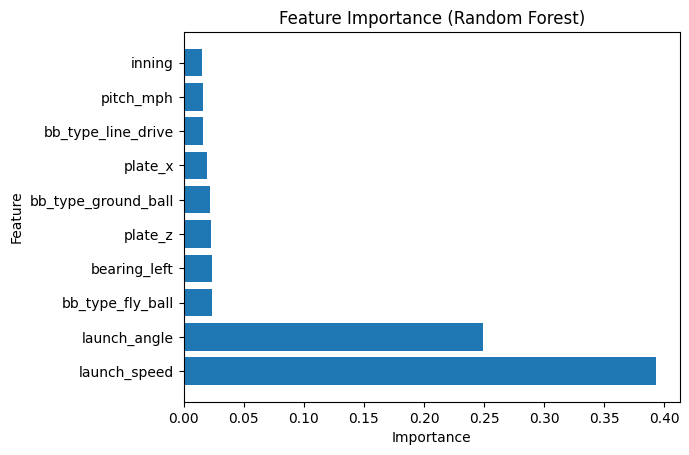

In [14]:
# Remove random_state for test data/prediction
# max_depth=10, n_estimators=5, random_state=123

param_rfModel = RandomForestClassifier(max_depth=10,n_estimators=5,random_state=123) # Best Params
param_rfModel.fit(X_train,y_train)

# Random Forest Classification
rfpredtrain = param_rfModel.predict(X_train)
print("Random Forest Param Report (Train Data):\n",classification_report(y_train,rfpredtrain))
rfpredtest = param_rfModel.predict(X_test)
print("Random Forest Param Report (Test Data):\n",classification_report(y_test,rfpredtest))

# Random Forest with best params to get feature importance
important_features = pd.DataFrame(
    data={"feature": param_rfModel.feature_names_in_,"importance": param_rfModel.feature_importances_,}
).sort_values("importance", ascending=False)

# Importance Plot of Top 10
plt.barh(important_features.head(10).feature, important_features.head(10).importance)
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title("Feature Importance (Random Forest)")
plt.show()